In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'placementdata.csv')

In [3]:
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [5]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [6]:
df.isna().sum()

StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [7]:
df.columns

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='object')

In [8]:
numerical_data = ['CGPA','Projects','Workshops/Certifications','AptitudeTestScore','SoftSkillsRating','SSC_Marks','HSC_Marks']

In [9]:
df.drop('StudentID', axis=1, inplace=True)

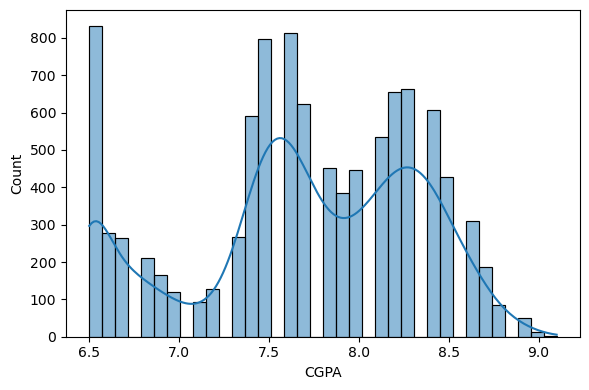

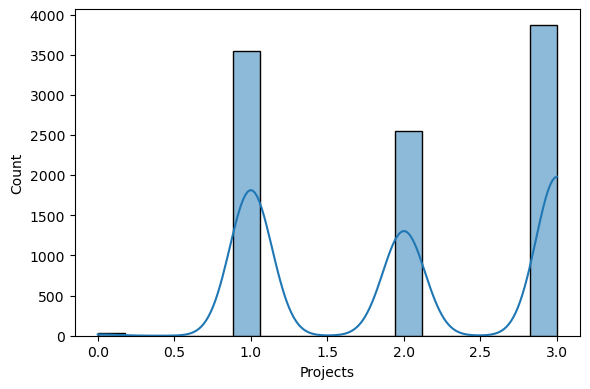

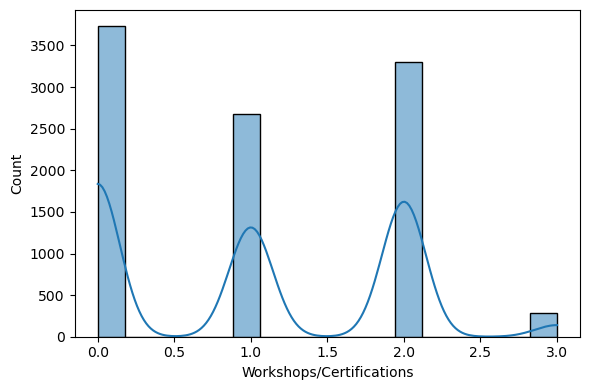

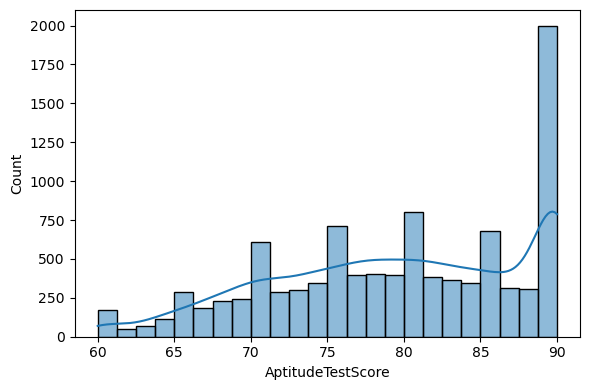

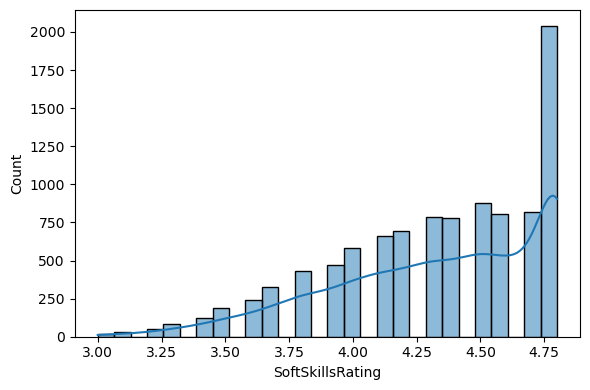

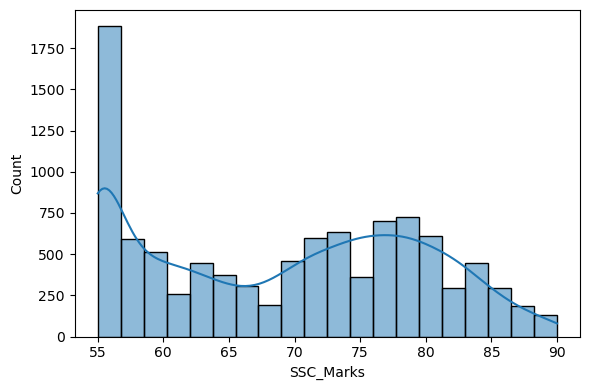

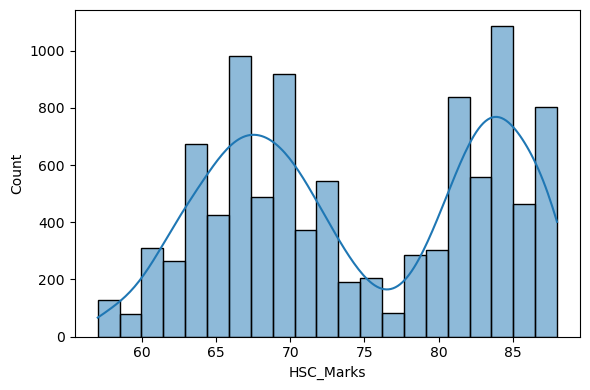

In [10]:
for col in numerical_data:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col ,kde=True)
    plt.tight_layout()

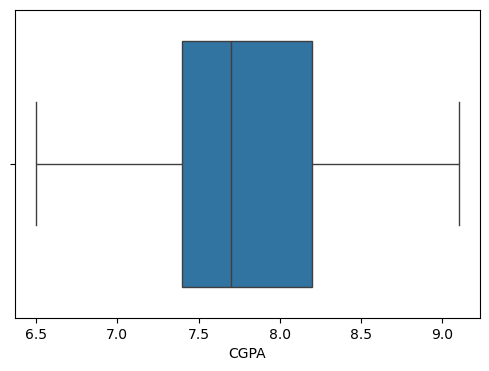

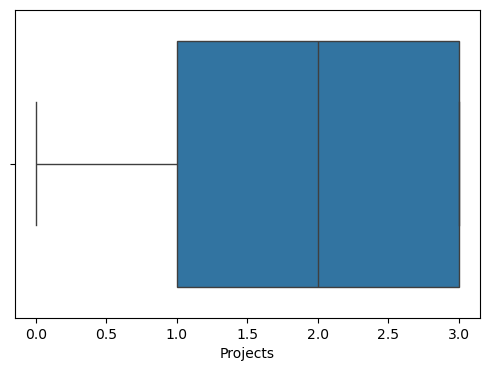

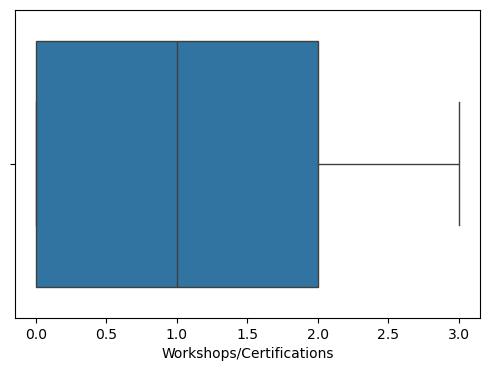

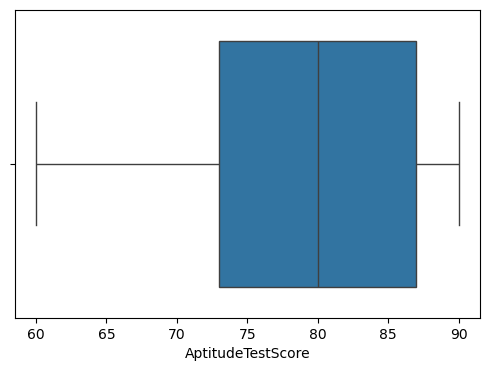

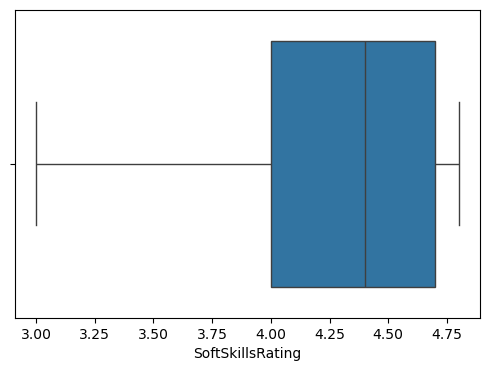

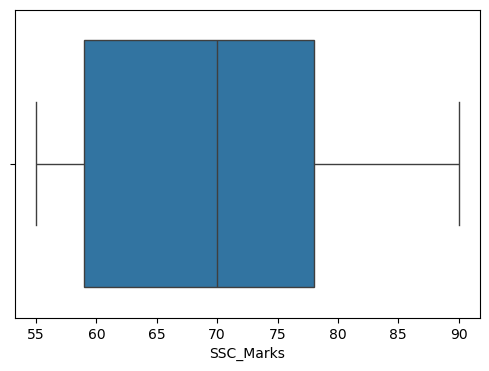

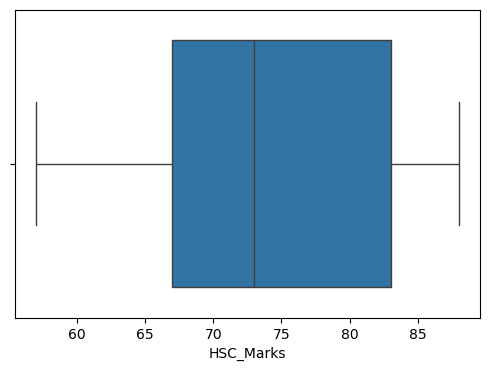

In [11]:
for col in numerical_data:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col])

In [12]:
df['ExtracurricularActivities'] = df['ExtracurricularActivities'].map({'Yes':1,'No':0})
df['PlacementTraining'] = df['PlacementTraining'].map({'Yes':1,'No':0})

In [13]:
df['AcademicScore'] = (
    df['CGPA'] * 10 +
    df['SSC_Marks'] +
    df['HSC_Marks']
) / 3


In [14]:
df['ExperienceScore'] = (
    df['Internships'] * 3 +
    df['Projects'] * 2 +
    df['Workshops/Certifications']
)

In [15]:
df['ProfileScore'] = (
    df['CGPA'] * 10 +
    df['Internships'] * 5 +
    df['Projects'] * 3 +
    df['Workshops/Certifications'] * 2 +
    df['SoftSkillsRating'] * 5
)

In [16]:
df['TrainingEffectiveness'] = (
    df['PlacementTraining'] *
    df['AptitudeTestScore']
)

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X = df.drop('PlacementStatus',axis=1)
y = df['PlacementStatus']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


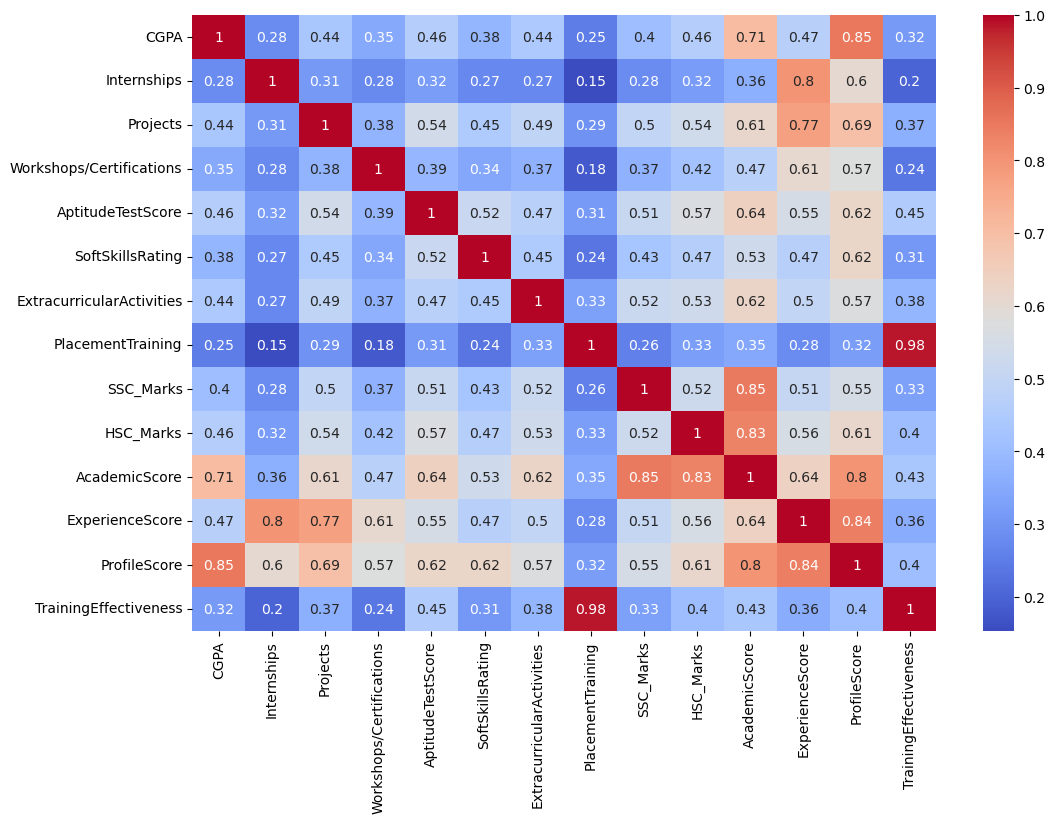

In [20]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm',annot=True)
plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
std = StandardScaler()
X_train_scaled= std.fit_transform(X_train)
X_test_scaled= std.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

models = {
    'LogisticRegression': LogisticRegression(),
    'SVM':SVC(kernel='rbf'),
    'DecisionTree':DecisionTreeClassifier(),
    'NaivesByes':GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=25)
}

In [24]:
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,

)

In [25]:
results = []

In [26]:
for name,model in models.items():
    model.fit(X_train_scaled,y_train_encoded)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test_encoded, y_pred)
    results.append({
        'Model':name,
        'Accuracy':acc
    })

In [27]:
results

[{'Model': 'LogisticRegression', 'Accuracy': 0.7945},
 {'Model': 'SVM', 'Accuracy': 0.7945},
 {'Model': 'DecisionTree', 'Accuracy': 0.719},
 {'Model': 'NaivesByes', 'Accuracy': 0.791},
 {'Model': 'KNN', 'Accuracy': 0.7915}]

In [28]:
df.columns

Index(['CGPA', 'Internships', 'Projects', 'Workshops/Certifications',
       'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities',
       'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus',
       'AcademicScore', 'ExperienceScore', 'ProfileScore',
       'TrainingEffectiveness'],
      dtype='object')

In [31]:
import joblib
joblib.dump(models['SVM'],'SVM_placement.pkl')
joblib.dump(std,'placement_scaler.pkl')
joblib.dump(X.columns.tolist(),'SVM_placement_columns.pkl')

['SVM_placement_columns.pkl']

In [32]:
X.columns.tolist()

['CGPA',
 'Internships',
 'Projects',
 'Workshops/Certifications',
 'AptitudeTestScore',
 'SoftSkillsRating',
 'ExtracurricularActivities',
 'PlacementTraining',
 'SSC_Marks',
 'HSC_Marks',
 'AcademicScore',
 'ExperienceScore',
 'ProfileScore',
 'TrainingEffectiveness']